# Battre la loss de Karpathy (dev ≈ 2.17)

In [1]:
# SETUP
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

random.seed(42)
ws = words[:]
random.shuffle(ws)
n1, n2 = int(0.8 * len(ws)), int(0.9 * len(ws))

def build_dataset(words, block_size):
	X, Y = [], []
	for w in words:
		context = [0] * block_size
		for ch in w + '.':
			ix = stoi[ch]
			X.append(context)
			Y.append(ix)
			context = context[1:] + [ix]
	return torch.tensor(X), torch.tensor(Y)

@torch.no_grad()
def split_loss(X, Y):
	emb = C[X]
	h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
	logits = h @ W2 + b2
	return F.cross_entropy(logits, Y).item()

runs = []  # historique des essais pour comparer

In [2]:
# HYPERPARAMÈTRES + INIT
block_size = 5     # taille du contexte
n_embd     = 24     # dimension de l'embedding
n_hidden   = 300    # neurones de la couche cachée
batch_size = 64
max_steps  = 150000
lr_sched   = [(0, 0.1), (50000, 0.01), (80000, 0.001), (120000, 0.0001)]  # (step de début, lr)
lam = 1e-4
seed  = 2608

Xtr,  Ytr  = build_dataset(ws[:n1],   block_size)
Xdev, Ydev = build_dataset(ws[n1:n2], block_size)
Xte,  Yte  = build_dataset(ws[n2:],   block_size)

g  = torch.Generator().manual_seed(seed)
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3) / (block_size * n_embd)**0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
	p.requires_grad = True

lossi = []
print(f"train {tuple(Xtr.shape)} | dev {tuple(Xdev.shape)} | params {sum(p.nelement() for p in parameters)}")

train (182625, 5) | dev (22655, 5) | params 45075


In [3]:
# ENTRAÎNEMENT
for i in range(max_steps):
	ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

	# forward
	emb = C[Xtr[ix]]
	h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Ytr[ix]) + lam * (W1**2).sum() + lam * (W2**2).sum()
	# backward
	for p in parameters:
		p.grad = None
	loss.backward()

	# update
	lr = [l for st, l in lr_sched if i >= st][-1]
	for p in parameters:
		p.data += -lr * p.grad

	lossi.append(loss.log10().item())
	if i % 10000 == 0:
		print(f"{i:7d}/{max_steps} {loss.item():.4f} dev {split_loss(Xdev, Ydev):.4f}")

      0/150000 3.3977 dev 3.1748
  10000/150000 2.3028 dev 2.1346
  20000/150000 1.9922 dev 2.1010
  30000/150000 1.9387 dev 2.0887
  40000/150000 2.1205 dev 2.0846
  50000/150000 2.0391 dev 2.0780
  60000/150000 1.9205 dev 2.0009
  70000/150000 1.9160 dev 1.9995
  80000/150000 1.8379 dev 2.0011
  90000/150000 1.6039 dev 1.9936
 100000/150000 1.8818 dev 1.9931
 110000/150000 1.7614 dev 1.9930
 120000/150000 1.9137 dev 1.9930
 130000/150000 1.9177 dev 1.9926
 140000/150000 1.8489 dev 1.9926


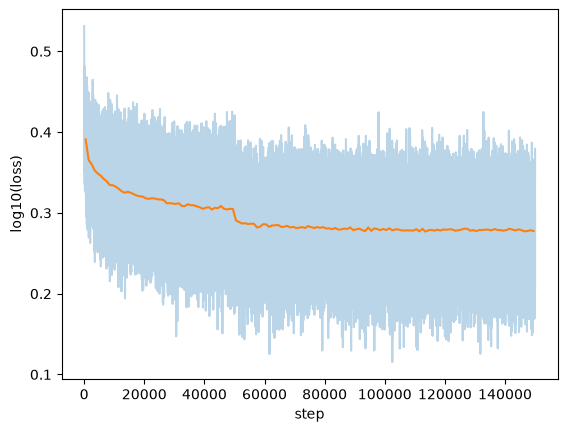

 # block embd hidden batch   steps                                                           lr     lam       seed   train     dev
 0     5   24    300    64  150000  [(0, 0.1), (50000, 0.01), (80000, 0.001), (120000, 0.0001)]  0.0001       2608  1.8227  1.9924


In [4]:
# ÉVALUATION + GRAPHE + COMPARAISON
tr, dv = split_loss(Xtr, Ytr), split_loss(Xdev, Ydev)
runs.append(dict(block=block_size, embd=n_embd, hidden=n_hidden, batch=batch_size,
                 steps=max_steps, lr=str(lr_sched), lam=lam, seed=seed, train=tr, dev=dv))

# courbe brute + moyenne par paquets de 1000 steps
k = 1000
smooth = torch.tensor(lossi[:len(lossi) // k * k]).view(-1, k).mean(1)
plt.plot(lossi, alpha=0.3)
plt.plot(torch.arange(len(smooth)) * k + k // 2, smooth)
plt.xlabel('step'); plt.ylabel('log10(loss)')
plt.show()

print(f"{'#':>2} {'block':>5} {'embd':>4} {'hidden':>6} {'batch':>5} {'steps':>7} {'lr':>60} {'lam':>7} {'seed':>10} {'train':>7} {'dev':>7}")
for j, r in enumerate(runs):
	print(f"{j:>2} {r['block']:>5} {r['embd']:>4} {r['hidden']:>6} {r['batch']:>5} {r['steps']:>7} {r['lr']:>60} {r['lam']:>7} {r['seed']:>10} {r['train']:>7.4f} {r['dev']:>7.4f}")

In [5]:
# ÉCHANTILLONNAGE
g_s = torch.Generator().manual_seed(seed + 10)
for _ in range(15):
	out, context = [], [0] * block_size
	while True:
		with torch.no_grad():
			emb = C[torch.tensor([context])]
			h = torch.tanh(emb.view(1, -1) @ W1 + b1)
			probs = F.softmax(h @ W2 + b2, dim=1)
		ix = torch.multinomial(probs, num_samples=1, generator=g_s).item()
		context = context[1:] + [ix]
		if ix == 0:
			break
		out.append(itos[ix])
	print(''.join(out))

kalesya
finla
fiqio
rhylynn
krinz
zacha
kymaya
ulissith
bes
jowen
cabelle
haydyn
sarnabell
geno
xarin


In [6]:
# TEST FINAL
split_loss(Xte, Yte)

1.9900165796279907